In [2]:
import os
from diffusers import MidiProcessor
from midi_player import MIDIPlayer
from midi_player.stylers import dark
import pretty_midi
import numpy as np
import matplotlib.pyplot as plt
import torch
from diffusers.pipelines.deprecated.spectrogram_diffusion.notes_encoder import (
    SpectrogramNotesEncoder,
)

torch.set_grad_enabled(False)

/home/finlay/miniconda/envs/midi-ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
in_file = "data/20240121-066-03_0050-0058.mid"
MIDIPlayer(
    in_file,
    330,
    styler=dark,
    title=os.path.basename(in_file),
)

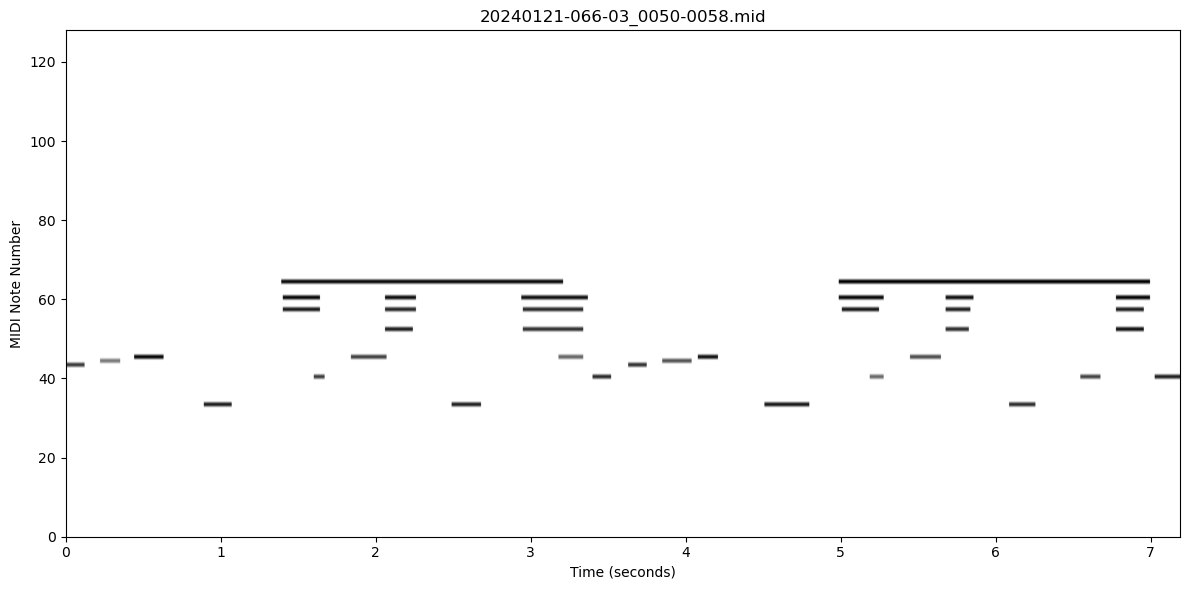

In [4]:
midi_data = pretty_midi.PrettyMIDI(in_file)
piano_roll = midi_data.get_piano_roll()
time_in_seconds = np.arange(piano_roll.shape[1]) / 100

# Plot piano roll
plt.figure(figsize=(12, 6))
plt.imshow(
    piano_roll,
    aspect="auto",
    origin="lower",
    cmap="grey_r",
    extent=[time_in_seconds[0], time_in_seconds[-1], 0, 128],
)
plt.title(os.path.basename(in_file))
plt.xlabel("Time (seconds)")
plt.ylabel("MIDI Note Number")

plt.tight_layout()
plt.show()

In [32]:
processor = MidiProcessor()
print(f"processing file, {in_file}")
tokens = processor(in_file)
print(torch.IntTensor(tokens).shape)
print(torch.IntTensor(tokens)[:, :20])
for tok_pool in tokens:
    print(np.count_nonzero(tok_pool))

processing file, data/20240121-066-03_0050-0058.mid
torch.Size([2, 2048])
tensor([[1134, 1135, 1133, 1047,   15, 1132, 1047,   26, 1133, 1048,   39, 1132,
         1048,   48, 1133, 1049,   66, 1132, 1049,   93],
        [1135, 1061, 1064, 1068, 1134,   11, 1133, 1044,   17, 1132, 1061,   19,
         1044, 1064,   36, 1133, 1049,   56, 1132, 1049]], dtype=torch.int32)
113
64


In [6]:
ENCODER_CONFIG = {
    "d_ff": 2048,
    "d_kv": 64,
    "d_model": 768,
    "dropout_rate": 0.1,
    "feed_forward_proj": "gated-gelu_pytorch_tanh",
    "is_decoder": False,
    "max_length": 2048,
    "num_heads": 12,
    "num_layers": 12,
    "vocab_size": 1536,
}
device = "cuda:1"
midi_encoder = SpectrogramNotesEncoder(**ENCODER_CONFIG).cuda(device=device)
midi_encoder.eval()
sd = torch.load("data/note_encoder.bin", weights_only=True)
midi_encoder.load_state_dict(sd)

<All keys matched successfully>

In [17]:
embeddings = []
for input_tokens in tokens:
    with torch.autocast("cuda"):
        input_tokens = torch.IntTensor(input_tokens).view(1, -1).cuda(device=device)
        print(f"loaded tokens {input_tokens.shape}")
        print(input_tokens[:, :20])
        tokens_mask = input_tokens > 0
        print(f"mask {tokens_mask.shape}")
        tokens_encoded, tokens_mask = midi_encoder(
            encoder_input_tokens=input_tokens,
            encoder_inputs_mask=tokens_mask,
        )
    print(f"generated embeddings {tokens_encoded.shape}")
    # TODO: normalize each embedding before storing it
    embeddings.extend(
        [
            enc[mask].mean(0).cpu().detach()
            for enc, mask in zip(tokens_encoded, tokens_mask)
        ]
    )
print(len(embeddings))
print(embeddings[0].shape)

loaded tokens torch.Size([1, 2048])
tensor([[1134, 1135, 1133, 1047,   15, 1132, 1047,   26, 1133, 1048,   39, 1132,
         1048,   48, 1133, 1049,   66, 1132, 1049,   93]], device='cuda:1',
       dtype=torch.int32)
mask torch.Size([1, 2048])
generated embeddings torch.Size([1, 2048, 768])
loaded tokens torch.Size([1, 2048])
tensor([[1135, 1061, 1064, 1068, 1134,   11, 1133, 1044,   17, 1132, 1061,   19,
         1044, 1064,   36, 1133, 1049,   56, 1132, 1049]], device='cuda:1',
       dtype=torch.int32)
mask torch.Size([1, 2048])
generated embeddings torch.Size([1, 2048, 768])
2
torch.Size([768])


In [18]:
embeddings = torch.vstack(embeddings)
embeddings.shape

torch.Size([2, 768])

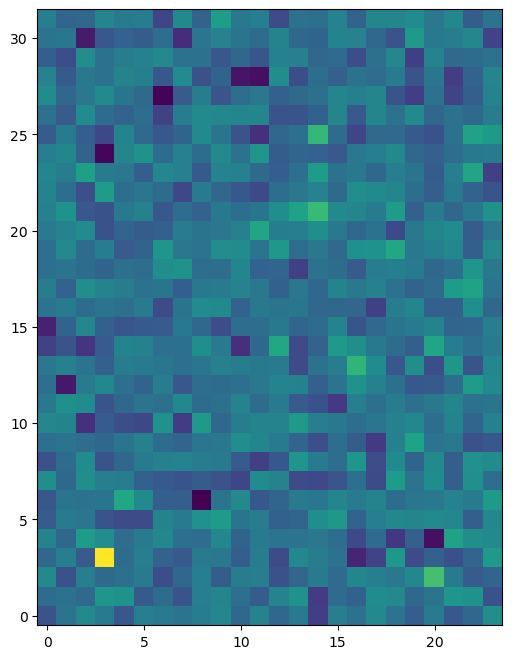

In [24]:
# Reshape to a roughly square matrix for visualization
reshaped_dim = (32, 24)  # Closest factors of 768 for a rectangular grid
reshaped_embedding = embeddings.mean(dim=0, keepdim=True).reshape(reshaped_dim)

# Plot heatmap using Matplotlib
plt.figure(figsize=(6, 8))
plt.imshow(reshaped_embedding, aspect="auto", cmap="viridis", origin="lower")
plt.show()